<a href="https://colab.research.google.com/github/Arkrishx/python-data-analytics-/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT: Food delivery insights

In [58]:
from google.colab import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv('food_delivery_data.csv')

print(df)



Saving food_delivery_data.csv to food_delivery_data (1).csv
    Order_ID Customer_ID  Order_Date Order_Time Day_of_Week      Location  \
0    ORD0001     CUST024  23-05-2025      12:47      Friday     Velachery   
1    ORD0002     CUST196  02-12-2024      13:48      Monday      Tambaram   
2    ORD0003     CUST076  28-03-2025      19:34      Friday   Kodambakkam   
3    ORD0004     CUST042  29-01-2025      09:55   Wednesday      Tambaram   
4    ORD0005     CUST164  16-04-2025      19:46   Wednesday  Nungambakkam   
5    ORD0006     CUST168  07-02-2025      14:04      Friday      Mylapore   
6    ORD0007     CUST013  29-04-2025      14:25     Tuesday      T. Nagar   
7    ORD0008     CUST138  15-04-2025      20:16     Tuesday         Porur   
8    ORD0009     CUST156  15-01-2025      20:32   Wednesday     Velachery   
9    ORD0010     CUST146  05-12-2024      20:07    Thursday      T. Nagar   
10   ORD0011     CUST139  20-04-2025      13:10      Sunday     Velachery   
11   ORD0012    

In [59]:
#checking duplicate records.

duplicate = df.duplicated()
print(duplicate)

0      False
1      False
2      False
3      False
4      False
5      False
6      False
7      False
8      False
9      False
10     False
11     False
12     False
13     False
14     False
15     False
16     False
17     False
18     False
19     False
20     False
21     False
22     False
23     False
24     False
25     False
26     False
27     False
28     False
29     False
30     False
31     False
32     False
33     False
34     False
35     False
36     False
37     False
38     False
39     False
40     False
41     False
42     False
43     False
44     False
45     False
46     False
47     False
48     False
49     False
50     False
51     False
52     False
53     False
54     False
55     False
56     False
57     False
58     False
59     False
60     False
61     False
62     False
63     False
64     False
65     False
66     False
67     False
68     False
69     False
70     False
71     False
72     False
73     False
74     False
75     False
76     False

In [ ]:
#There is no duplicate records. so it is a cleaned dataset

In [60]:
#Finding the number of null records
print(df.isnull().sum())

Order_ID              0
Customer_ID           0
Order_Date            0
Order_Time            0
Day_of_Week           0
Location              0
Food_Item             0
Category              0
Quantity              0
Unit_Price            0
Total_Amount          0
Delivery_Fee          0
Grand_Total           0
Payment_Method        0
Delivery_Time_Min    45
Customer_Rating      79
dtype: int64


In [61]:
#Assigning mean value for NaN in delivery time and customer rating records

# Ensure columns are numeric, coercing errors to NaN
df['Delivery_Time_Min'] = pd.to_numeric(df['Delivery_Time_Min'], errors='coerce')
df['Customer_Rating'] = pd.to_numeric(df['Customer_Rating'], errors='coerce')

delivery_time_mean = df['Delivery_Time_Min'].mean().round(2)
customer_rating_mean = df['Customer_Rating'].mean().round(2)
print(delivery_time_mean)
print(customer_rating_mean)

df['Delivery_Time_Min'].fillna(delivery_time_mean, inplace=True)
df['Customer_Rating'].fillna(customer_rating_mean, inplace=True)

print(df.isnull().sum())
print("\nDelivery time:\n",df['Delivery_Time_Min'])
print("\nCustomer rating:\n",df['Customer_Rating'])

40.49
3.72
Order_ID             0
Customer_ID          0
Order_Date           0
Order_Time           0
Day_of_Week          0
Location             0
Food_Item            0
Category             0
Quantity             0
Unit_Price           0
Total_Amount         0
Delivery_Fee         0
Grand_Total          0
Payment_Method       0
Delivery_Time_Min    0
Customer_Rating      0
dtype: int64

Delivery time:
 0      25.00
1      47.00
2      44.00
3      37.00
4      49.00
5      56.00
6      28.00
7      20.00
8      60.00
9      39.00
10     58.00
11     40.49
12     28.00
13     26.00
14     48.00
15     23.00
16     54.00
17     35.00
18     36.00
19     42.00
20     28.00
21     23.00
22     27.00
23     22.00
24     46.00
25     49.00
26     21.00
27     36.00
28     40.00
29     59.00
30     30.00
31     40.49
32     26.00
33     58.00
34     60.00
35     29.00
36     56.00
37     40.49
38     49.00
39     23.00
40     33.00
41     56.00
42     22.00
43     29.00
44     35.00
45    

/tmp/ipykernel_4315/919255110.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_Time_Min'].fillna(delivery_time_mean, inplace=True)
/tmp/ipykernel_4315/919255110.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [62]:
max_delivery_time = df['Delivery_Time_Min'].max()
min_delivery_time = df['Delivery_Time_Min'].min()

print("\nMaximum delivery time:",max_delivery_time,"Min")
print("\nMinimum delivery time:",min_delivery_time,"Min")


Maximum delivery time: 60.0 Min

Minimum delivery time: 20.0 Min


In [63]:
#payment method insights

payment_method_count = df['Payment_Method'].value_counts()
print(payment_method_count)

Payment_Method
Credit Card    108
UPI            105
Wallet          99
Cash            94
Debit Card      94
Name: count, dtype: int64


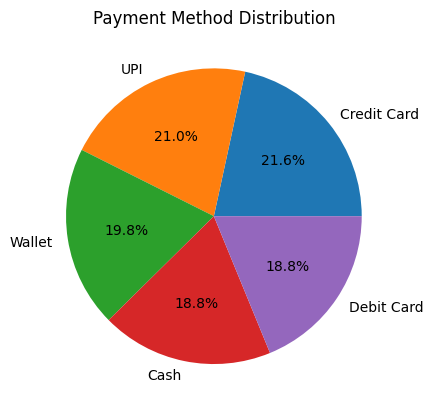

In [64]:
#payment method pie chart

plt.pie(payment_method_count, labels=payment_method_count.index,autopct="%0.1f%%")
plt.title('Payment Method Distribution')
plt.show()

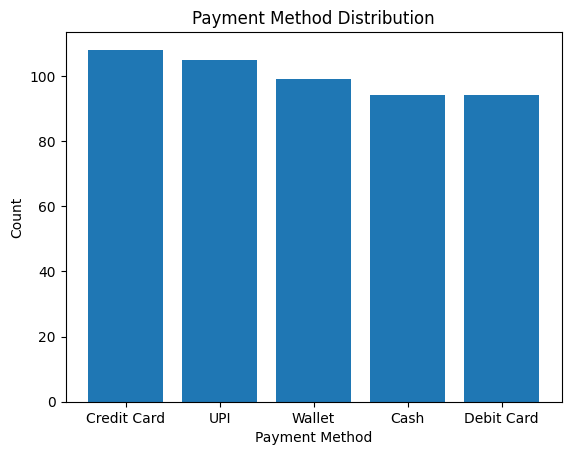

In [65]:
#payment method bar chart

plt.bar(payment_method_count.index, payment_method_count.values)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [66]:
#date count insights

Date_count = df['Order_Date'].value_counts()
print("\n",Date_count)


 Order_Date
09-04-2025    7
24-12-2024    7
25-03-2025    7
05-04-2025    6
22-01-2025    6
22-12-2024    6
22-03-2025    6
28-12-2024    6
04-05-2025    6
09-12-2024    6
21-03-2025    6
16-01-2025    6
17-03-2025    5
30-12-2024    5
24-02-2025    5
28-04-2025    5
31-03-2025    5
17-01-2025    5
30-05-2025    5
02-02-2025    5
23-05-2025    5
07-02-2025    5
15-02-2025    5
13-02-2025    5
19-01-2025    5
13-04-2025    5
30-01-2025    5
28-03-2025    4
26-03-2025    4
11-01-2025    4
29-04-2025    4
28-05-2025    4
15-04-2025    4
21-05-2025    4
05-01-2025    4
07-01-2025    4
31-12-2024    4
20-02-2025    4
24-05-2025    4
11-02-2025    4
09-02-2025    4
01-03-2025    4
08-02-2025    4
07-03-2025    4
14-02-2025    4
02-05-2025    4
04-01-2025    4
25-05-2025    4
21-04-2025    4
01-04-2025    4
18-05-2025    4
28-02-2025    4
07-04-2025    4
19-02-2025    4
26-04-2025    4
29-01-2025    3
02-12-2024    3
10-04-2025    3
27-12-2024    3
07-12-2024    3
20-03-2025    3
12-02-2025 

Text(0, 0.5, 'Count')

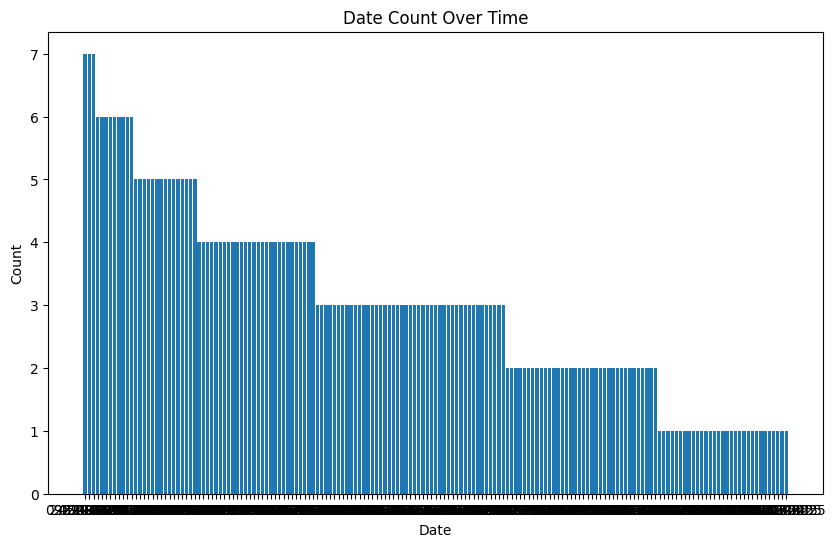

In [67]:
#line chart of Date count

plt.figure(figsize=(10, 6))
plt.bar(Date_count.index, Date_count.values)
plt.title('Date Count Over Time')
plt.xlabel('Date')
plt.ylabel('Count')

In [68]:
#Days count insights

Days_count = df['Day_of_Week'].value_counts()
print(Days_count)

Day_of_Week
Saturday     77
Sunday       76
Monday       74
Tuesday      73
Friday       70
Wednesday    69
Thursday     61
Name: count, dtype: int64


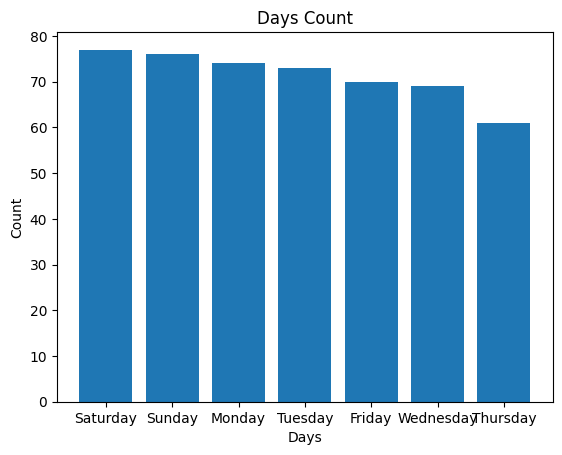

In [69]:
#Days count bar chart

plt.bar(Days_count.index, Days_count.values)
plt.title('Days Count')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

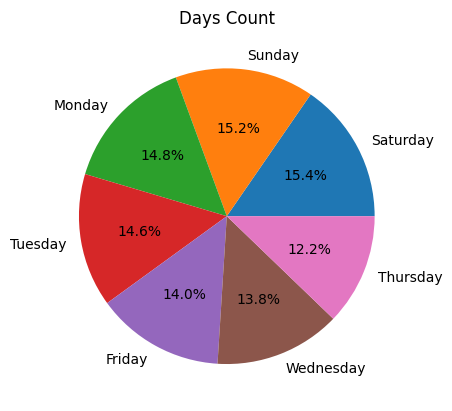

In [70]:
#Days count pie chart

plt.pie(Days_count, labels=Days_count.index,autopct="%0.1f%%")
plt.title('Days Count')
plt.show()

In [71]:
#categories count

Categories_count = df['Category'].value_counts()
print(Categories_count)

Category
Fast Food       109
South Indian    109
Rice Dishes      99
Curry            83
Chinese          53
North Indian     37
Italian          10
Name: count, dtype: int64


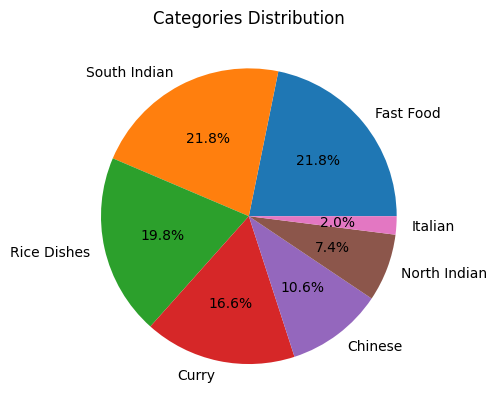

In [72]:
#categories pi chart

plt.pie(Categories_count, labels=Categories_count.index,autopct="%0.1f%%")
plt.title('Categories Distribution')
plt.show()

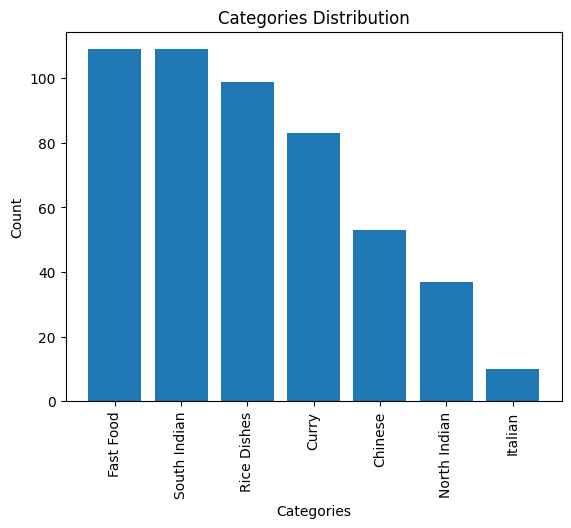

In [74]:
#categories bar chart

plt.bar(Categories_count.index, Categories_count.values)
plt.title('Categories Distribution')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [75]:
#Food items count

Food_items_count = df['Food_Item'].value_counts()
print(Food_items_count)

Food_Item
Biryani                 64
Chicken Curry           54
Dosa                    47
Burger                  44
Pizza                   38
Fried Rice              35
Idli Sambar             32
Noodles                 31
Parotta                 30
Paneer Butter Masala    29
Shawarma                27
Manchurian              22
Chole Bhature           19
Dal Tadka               18
Pasta                   10
Name: count, dtype: int64


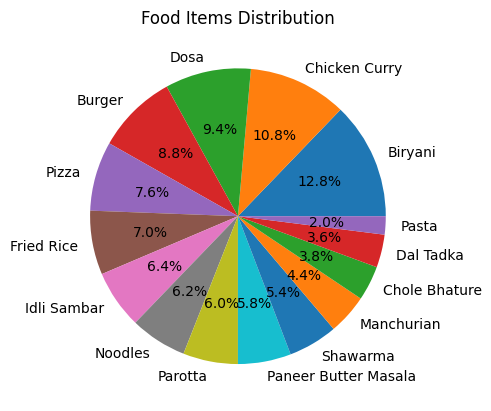

In [77]:
#food item pie chart

plt.pie(Food_items_count, labels=Food_items_count.index,autopct="%0.1f%%")
plt.title('Food Items Distribution')

plt.show()

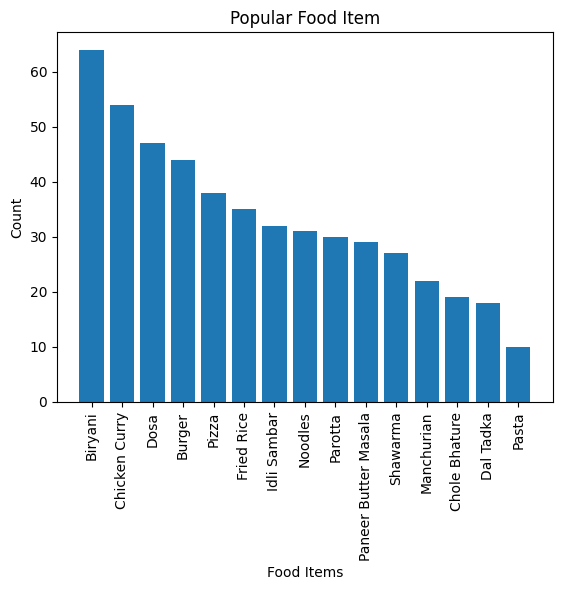

In [78]:
plt.bar(Food_items_count.index,Food_items_count.values)
plt.title('Popular Food Item')
plt.xlabel('Food Items')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [79]:
#food item quantity wise

food_item_quantity = df.groupby('Food_Item')['Quantity'].sum()
print(food_item_quantity)

Food_Item
Biryani                 108
Burger                   85
Chicken Curry            97
Chole Bhature            31
Dal Tadka                31
Dosa                     77
Fried Rice               63
Idli Sambar              59
Manchurian               41
Noodles                  52
Paneer Butter Masala     49
Parotta                  50
Pasta                    16
Pizza                    61
Shawarma                 55
Name: Quantity, dtype: int64


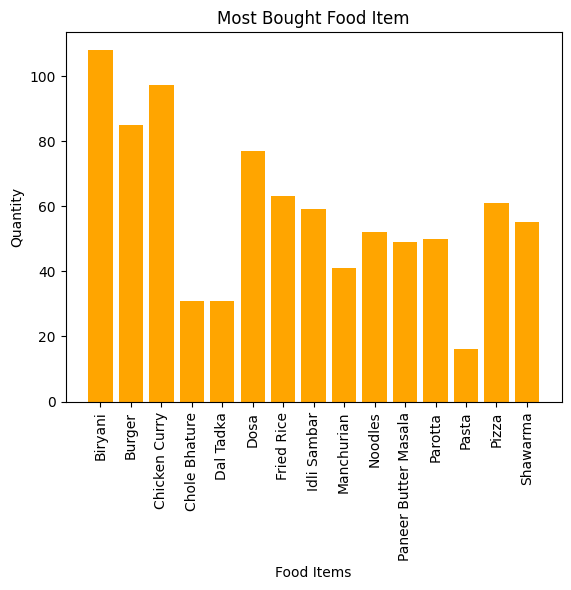

In [80]:
#most bought food item in bar chart

plt.bar(food_item_quantity.index,food_item_quantity.values,color = "Orange")
plt.title('Most Bought Food Item')
plt.xlabel('Food Items')
plt.ylabel('Quantity')
plt.xticks(rotation=90)
plt.show()

In [81]:
#Location count

location_count = df['Location'].value_counts()
print(location_count)

Location
Velachery       61
Mylapore        56
Porur           55
Tambaram        51
T. Nagar        49
Anna Nagar      47
Adyar           46
Chromepet       46
Kodambakkam     45
Nungambakkam    44
Name: count, dtype: int64


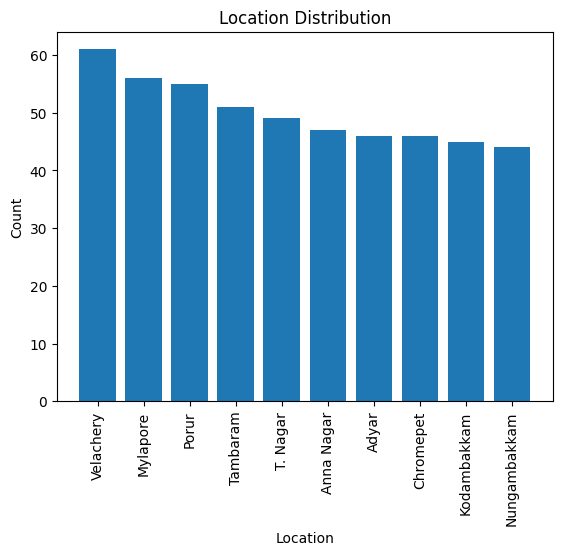

In [82]:
#location bar chart

plt.bar(location_count.index,location_count.values)
plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [37]:
#category wise food items using groupby method

category_food_items = df.groupby('Category')['Food_Item'].value_counts()
print(category_food_items)

Category      Food_Item           
Chinese       Noodles                 31
              Manchurian              22
Curry         Chicken Curry           54
              Paneer Butter Masala    29
Fast Food     Burger                  44
              Pizza                   38
              Shawarma                27
Italian       Pasta                   10
North Indian  Chole Bhature           19
              Dal Tadka               18
Rice Dishes   Biryani                 64
              Fried Rice              35
South Indian  Dosa                    47
              Idli Sambar             32
              Parotta                 30
Name: count, dtype: int64


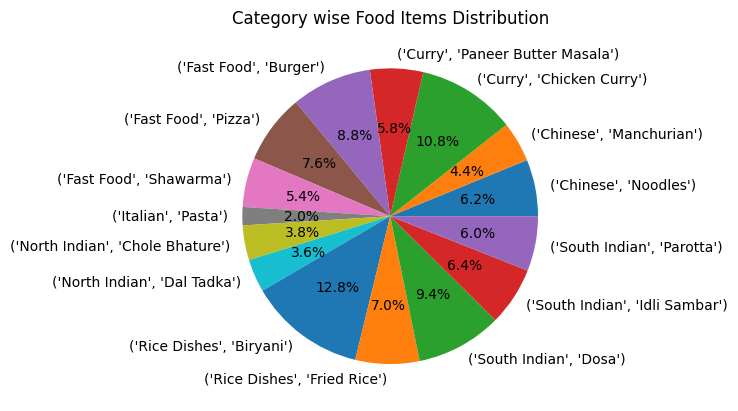

In [83]:
plt.pie(category_food_items, labels=category_food_items.index,autopct="%0.1f%%")
plt.title('Category wise Food Items Distribution')
plt.show()

In [84]:
#unit price

max_unitprice = df['Unit_Price'].max()
min_unitprice = df['Unit_Price'].min()
avg_unitprice = df['Unit_Price'].mean()

print(max_unitprice)
print(min_unitprice)
print(avg_unitprice)

270
40
135.89


In [85]:
#max & min price items

max_costitem = df[df['Unit_Price']==max_unitprice]['Food_Item'].unique()
min_costitem = df[df['Unit_Price']==min_unitprice]['Food_Item'].unique()

print(max_costitem)
print(min_costitem)

['Pizza']
['Idli Sambar']


In [86]:
#delivery fee

free_delivery_area = df[df['Delivery_Fee']==0]['Location'].value_counts()
print("Free delivery count area wise:\n",free_delivery_area)

max_delfee = df['Delivery_Fee'].max()
min_delfee = df['Delivery_Fee'].min()

print("\nMaximum delivery Fee:",max_delfee)
print("Minimum delivery Fee:",min_delfee)

Free delivery count area wise:
 Location
Adyar           18
Mylapore        15
Nungambakkam    12
Chromepet       12
Tambaram        12
Velachery       12
T. Nagar        11
Anna Nagar      11
Kodambakkam      9
Porur            8
Name: count, dtype: int64

Maximum delivery Fee: 40
Minimum delivery Fee: 0


In [89]:
#customer insights

customer = df['Customer_ID'].value_counts()
print(customer)

Customer_ID
CUST167    9
CUST185    8
CUST172    7
CUST109    7
CUST054    7
CUST147    7
CUST124    7
CUST076    6
CUST138    6
CUST093    6
CUST166    6
CUST180    6
CUST026    6
CUST168    6
CUST102    5
CUST095    5
CUST117    5
CUST169    5
CUST126    5
CUST145    5
CUST144    5
CUST099    5
CUST012    5
CUST127    5
CUST189    5
CUST084    4
CUST173    4
CUST036    4
CUST132    4
CUST107    4
CUST175    4
CUST130    4
CUST016    4
CUST043    4
CUST015    4
CUST066    4
CUST078    4
CUST157    4
CUST075    4
CUST021    4
CUST182    4
CUST079    4
CUST077    4
CUST001    4
CUST002    4
CUST148    4
CUST024    4
CUST091    4
CUST092    4
CUST073    4
CUST050    4
CUST020    3
CUST040    3
CUST025    3
CUST165    3
CUST115    3
CUST018    3
CUST113    3
CUST047    3
CUST088    3
CUST087    3
CUST111    3
CUST069    3
CUST186    3
CUST191    3
CUST170    3
CUST177    3
CUST114    3
CUST125    3
CUST104    3
CUST063    3
CUST042    3
CUST013    3
CUST164    3
CUST196    3
CUST146    3


In [93]:
#Total amount

max_total_amount = df['Total_Amount'].max()
min_total_amount = df['Total_Amount'].min()


print(max_total_amount)
print(min_total_amount)


1044
40


In [94]:
#High purchae customer

high_purchase_customer = df[df['Total_Amount']==max_total_amount]['Customer_ID'].unique()
print(high_purchase_customer)

['CUST162']


In [96]:
#Totalrevenue

total_revenue = df['Grand_Total'].sum()
print(total_revenue,"₹")

129233 ₹


1. payment method - pie chart                     @@@
2. Day of week - Bar chart                        @@@
3. Location - Bar chart                           @@@
4. Day - Bar chart                                @@@
5. Date - line chart                               *
6. Food Categories - Bar chart                    @@@
7. Food items - Bar chart                         @@@
8. Food categories items - pie chart               *
9. location - Bar chart                           @@@
10. Time (seperate as 6) - ? chart                 *
11. customer rating - Mean value assigning        @@@
12. Delivery time - Mean value assign             @@@
13. Free delivery area finding                     *
14. area wise food trends                          *
15. quantity wise food order analysis              *
16. delivery-order, Grand-total, Total amount      *
17. maximum & minimum delivery time & Mean         @@@
18. Rating Nan count Mean value                    @@@
19. Food- unit price                               *

**To be done**
1. date
2. time


---



**Completed**
1. Day
2. Location
3. Food items(popular,most buyed)
4. category(normal,items wise)
5. Quantity used in food item(most buyed food itmes)
6. Cost item(max,min,mean,and its name)
7. Delivery fee(free delivery area,max and min)
8. Customer id (order count)
9. Grand total(total revenue)
10. total amount(max & min and the customer name)
11. Payment method
12. Delivery time
13. Customer rating

